In [7]:
#prendo i dati combinati dei vari soggetti
import pandas as pd

subject1 = pd.read_csv('A1/combined_results.csv')
subject2 = pd.read_csv('A2/combined_results.csv')
subject3 = pd.read_csv('A3/combined_results.csv')
subject4 = pd.read_csv('A4/combined_results.csv')
subject5 = pd.read_csv('A5/combined_results.csv')
subject6 = pd.read_csv('A6/combined_results.csv')
subject7 = pd.read_csv('A7/combined_results.csv')
subject8 = pd.read_csv('A8/combined_results.csv')
subject9 = pd.read_csv('A9/combined_results.csv')

# Unisco i dati in un unico DataFrame
combined_data = pd.concat([subject1, subject2, subject3, subject4, subject5, subject6, subject7, subject8, subject9], ignore_index=True)

In [14]:
#salvo i dati combinati in un file CSV
combined_data.to_csv('mwl_BCI2a.csv', index=False)

In [8]:
combined_data

,trial,true_label,pred_label,label,theta_alpha,channel_idx
0,1,0,0,0,1.207481,11
1,2,1,1,1,1.394684,11
2,3,1,1,1,1.504618,11
3,4,0,0,0,1.941802,11
4,5,1,1,1,1.216778,11
...,...,...,...,...,...,...
2587,284,2,2,2,0.166430,11
2588,285,3,3,3,0.167849,11
2589,286,2,2,2,0.257325,11
2590,287,0,0,0,0.326553,11


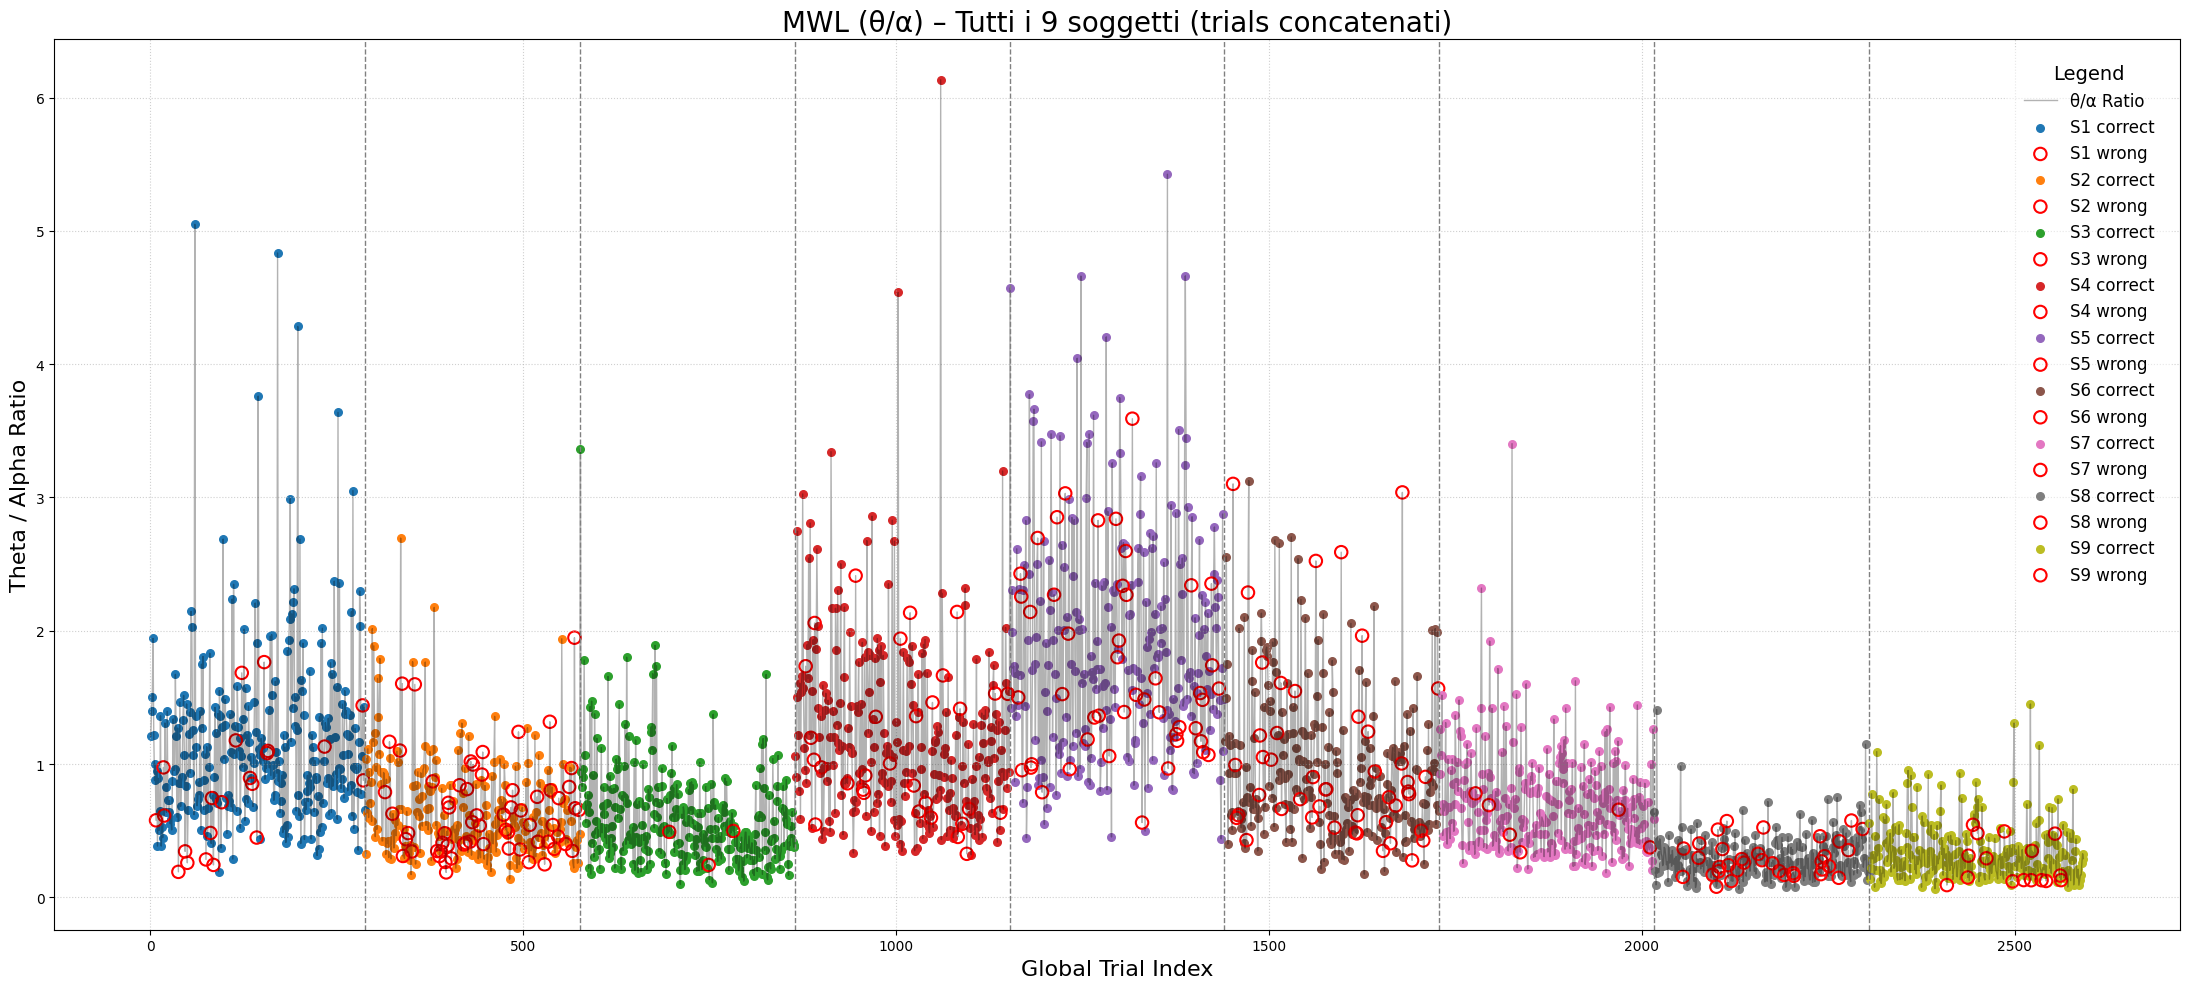

Grafico combinato salvato in 'mwl_combined_plot.png'


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ——— 1) Lettura e concatenazione dei CSV per ciascun soggetto ———
dfs = []
for sub in range(1, 10):
    df = pd.read_csv(f'A{sub}/combined_results.csv')
    df['subject'] = sub
    dfs.append(df)
combined = pd.concat(dfs, ignore_index=True)

# ——— 2) Calcolo dell’indice "global_trial" ———
combined = combined.sort_values(['subject','trial']).reset_index(drop=True)
counts = combined.groupby('subject').size().to_dict()
offset = {}
cum = 0
for sub in range(1,10):
    offset[sub] = cum
    cum += counts[sub]
combined['global_trial'] = combined.apply(
    lambda row: row['trial'] + offset[row['subject']], axis=1
)

# ——— 3) Prepara la figura ———
fig, ax = plt.subplots(figsize=(22, 10))

# 3a) Palette di colori
colors = plt.cm.tab10.colors
sub_colors = {sub: colors[(sub-1) % len(colors)] for sub in range(1,10)}

# 3b) Linea complessiva θ/α
ax.plot(combined['global_trial'], combined['theta_alpha'],
        color='black', linewidth=1, alpha=0.3, label='θ/α Ratio')

# 3c) Scatter per soggetto
for sub, grp in combined.groupby('subject'):
    correct = grp['pred_label'] == grp['true_label']
    # corretti: markers pieni colorati
    ax.scatter(grp.loc[correct,'global_trial'],
               grp.loc[correct,'theta_alpha'],
               color=sub_colors[sub], s=30, label=f'S{sub} correct')
    # errati: cerchi vuoti con bordo rosso
    ax.scatter(grp.loc[~correct,'global_trial'],
               grp.loc[~correct,'theta_alpha'],
               edgecolors='red', facecolors='none', s=80,
               linewidths=1.5, label=f'S{sub} wrong')

# ——— 4) Linee tratteggiate di separazione soggetto ———
boundaries = np.cumsum([counts[sub] for sub in range(1,10)])[:-1]
for b in boundaries:
    ax.axvline(x=b + 0.5, color='gray', linestyle='--', linewidth=1)

# ——— 5) Titoli, etichette e griglia ———
ax.set_title("MWL (θ/α) – Tutti i 9 soggetti (trials concatenati)", fontsize=20)
ax.set_xlabel("Global Trial Index", fontsize=16)
ax.set_ylabel("Theta / Alpha Ratio", fontsize=16)
ax.grid(True, linestyle=':', alpha=0.6)

# ——— 6) Legenda interna e compatta ———
handles, labels = ax.get_legend_handles_labels()
# Prendi solo la prima occorrenza
unique = dict(zip(labels, handles))
leg = ax.legend(unique.values(), unique.keys(),
                loc='upper right', fontsize=12,
                title="Legend", title_fontsize=14,
                framealpha=0.5, frameon=True,
                borderpad=1)
# Facoltativo: riquadro arrotondato
leg.get_frame().set_linewidth(0)

# ——— 7) Layout e salvataggio ———
plt.tight_layout()
plt.savefig('mwl_combined_plot.png', dpi=300)
plt.show()
print("Grafico combinato salvato in 'mwl_combined_plot.png'")  
